# 10 — Inference and model debugging: trace one prediction end to end

Training is only half the lifecycle. At inference time there is **no backpropagation**. We freeze parameters and ask what happens to one unseen sample.

## What you should learn
- exact inference path from raw pixels to probability;
- how to inspect hidden activations for one sample;
- occlusion sensitivity: which image regions affect the score;
- confidence is not the same as correctness;
- production validation checks around shape, range, and drift.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
d=load_digits();m=np.isin(d.target,[0,1]);X=d.data[m]/16.;y=(d.target[m]==1).astype(float).reshape(-1,1)
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.25,random_state=42,stratify=y)
# train deterministic small numpy model
rng=np.random.default_rng(10);W1=rng.normal(0,.15,(64,8));b1=np.zeros((1,8));W2=rng.normal(0,.15,(8,1));b2=np.zeros((1,1));sig=lambda z:1/(1+np.exp(-z))
for _ in range(350):
    z1=Xtr@W1+b1;h=np.tanh(z1);p=sig(h@W2+b2);dz=(p-ytr)/len(Xtr);dW2=h.T@dz;dh=dz@W2.T;dz1=dh*(1-h**2);dW1=Xtr.T@dz1;W2-=.6*dW2;b2-=.6*dz.sum(0,keepdims=True);W1-=.6*dW1;b1-=.6*dz1.sum(0,keepdims=True)


## 1. One unseen sample trace


target= 0 logit= -7.137012848108105 probability class 1= 0.0007944919883937452


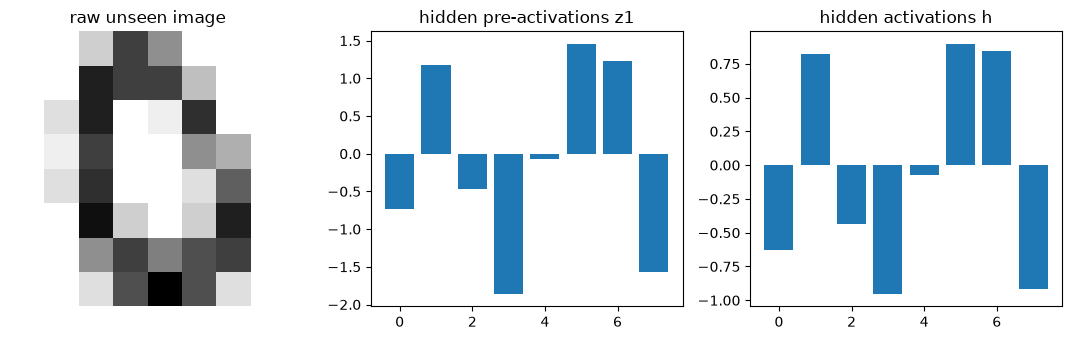

In [2]:
i=5;x=Xte[i:i+1];target=int(yte[i,0]);z1=x@W1+b1;h=np.tanh(z1);logit=h@W2+b2;prob=sig(logit)
print('target=',target,'logit=',logit.item(),'probability class 1=',prob.item())
fig,axes=plt.subplots(1,3,figsize=(11,3.5));axes[0].imshow(x.reshape(8,8),cmap='gray_r');axes[0].set_title('raw unseen image');axes[0].axis('off');axes[1].bar(range(8),z1.ravel());axes[1].set_title('hidden pre-activations z1');axes[2].bar(range(8),h.ravel());axes[2].set_title('hidden activations h');plt.tight_layout();plt.show()


## 2. Occlusion sensitivity
Set one pixel to zero at a time and measure the change in output probability. This is not a perfect explanation method, but it is a direct causal perturbation test.


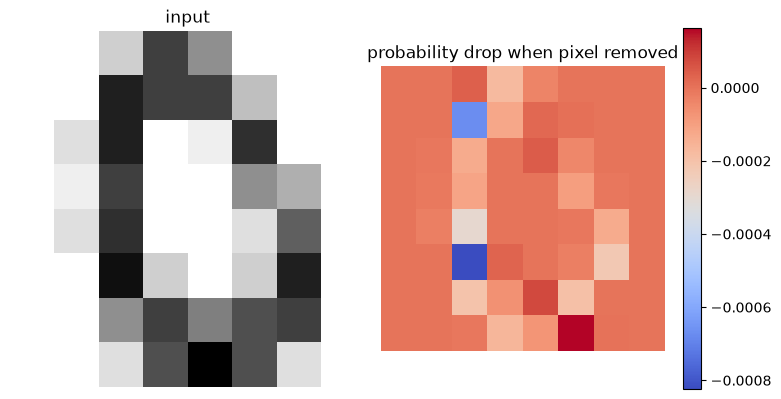

In [3]:
base=prob.item();impact=np.zeros(64)
for j in range(64):
    xx=x.copy();xx[0,j]=0;hh=np.tanh(xx@W1+b1);pp=sig(hh@W2+b2).item();impact[j]=base-pp
fig,axes=plt.subplots(1,2,figsize=(8,4));axes[0].imshow(x.reshape(8,8),cmap='gray_r');axes[0].set_title('input');axes[0].axis('off');im=axes[1].imshow(impact.reshape(8,8),cmap='coolwarm');axes[1].set_title('probability drop when pixel removed');axes[1].axis('off');plt.colorbar(im,ax=axes[1]);plt.tight_layout();plt.show()


## 3. Confidence vs correctness across the test set


In [4]:
hte=np.tanh(Xte@W1+b1);pte=sig(hte@W2+b2).ravel();pred=(pte>=.5).astype(int);truth=yte.ravel().astype(int);conf=np.maximum(pte,1-pte);correct=pred==truth
bins=np.linspace(.5,1,6);rows=[]
for lo,hi in zip(bins[:-1],bins[1:]):
    mask=(conf>=lo)&(conf<(hi if hi<1 else hi+1e-9));rows.append([lo,hi,mask.sum(),correct[mask].mean() if mask.any() else np.nan])
pd.DataFrame(rows,columns=['confidence low','confidence high','count','accuracy'])


,confidence low,confidence high,count,accuracy
0,0.5,0.6,1,0.0
1,0.6,0.7,0,NaN
2,0.7,0.8,0,NaN
3,0.8,0.9,1,1.0
4,0.9,1.0,88,1.0


## 4. Production guardrails
Before inference, validate:
- feature count/shape;
- numeric dtype and finite values;
- expected input range;
- preprocessing version;
- drift in feature and score distributions;
- latency and throughput;
- confidence/abstention policy.

A model can be mathematically correct and still fail in production because the **data contract** changed.
